In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

dataset_name = "numerai28.6"
explainer_name = "shap"
strategy = "kernel"
metrics = ["mae", "top_k", "mmd", "compression_time"]
model = "ann"

In [23]:
data = pd.read_csv(f"package_metadata/openml/{dataset_name}/kernels_iid_comparison/{explainer_name}_{strategy}_{model}_kernels_iid_42_10.csv")
data["kernel"] = data["kernel"].replace("Not needed", "iid")
sizes = sorted(data["size"].unique())
data = data[data["kernel"] != "sobolev"]
# data = data[data["kernel"] != "iid"]

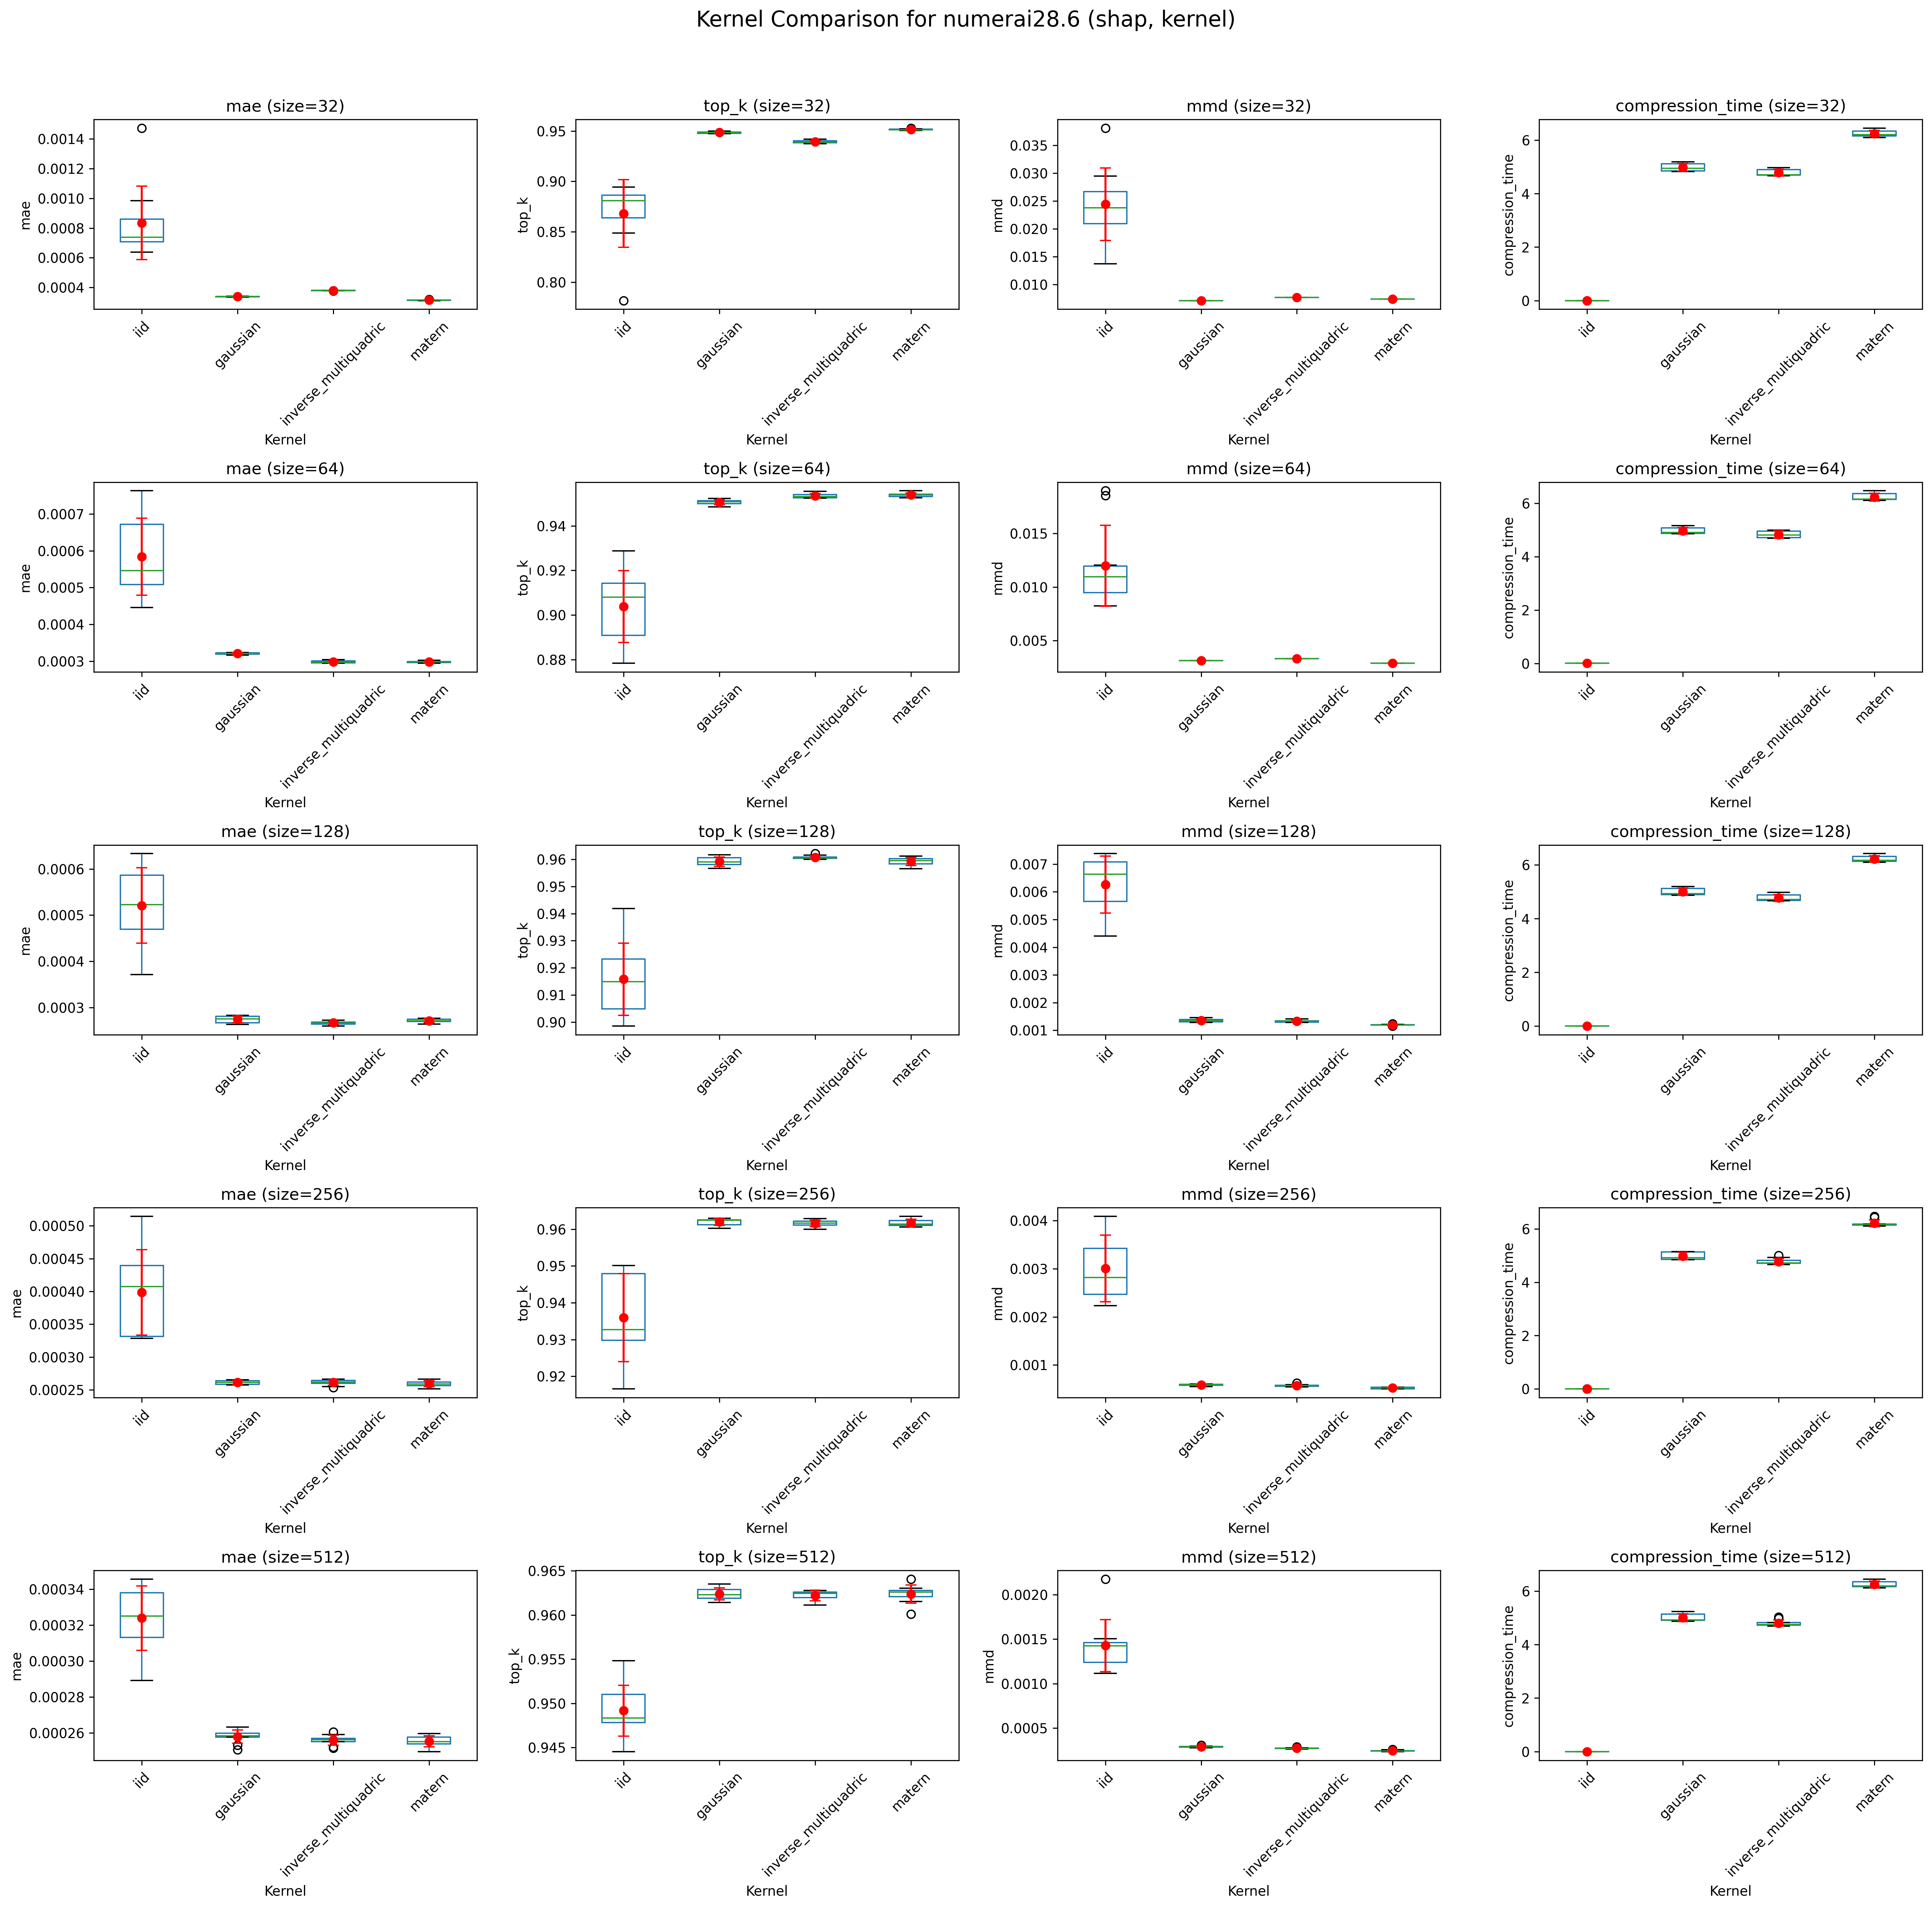

In [24]:
kernels_order = ["iid"] + [k for k in sorted(data['kernel'].unique()) if k != "iid"]

fig, axes = plt.subplots(len(sizes), len(metrics), figsize=(5 * len(metrics), 4 * len(sizes)), squeeze=False, dpi=300)
fig.suptitle(f'Kernel Comparison for {dataset_name} ({explainer_name}, {strategy})', fontsize=16)

for i, size in enumerate(sizes):
    filtered = data[data['size'] == size]
    filtered['kernel'] = pd.Categorical(filtered['kernel'], categories=kernels_order, ordered=True)
    for j, metric in enumerate(metrics):
        ax = axes[i, j]
        filtered.boxplot(column=metric, by='kernel', ax=ax, grid=False)
        means = filtered.groupby('kernel')[metric].mean().reindex(kernels_order)
        stds = filtered.groupby('kernel')[metric].std().reindex(kernels_order)
        ax.errorbar(
            x=range(1, len(means) + 1),
            y=means,
            yerr=stds,
            fmt='o',
            color='red',
            capsize=4
        )
        ax.set_title(f'{metric} (size={size})')
        ax.set_xlabel('Kernel')
        ax.set_ylabel(metric)
        ax.tick_params(axis='x', rotation=45)

plt.suptitle(f'Kernel Comparison for {dataset_name} ({explainer_name}, {strategy})', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


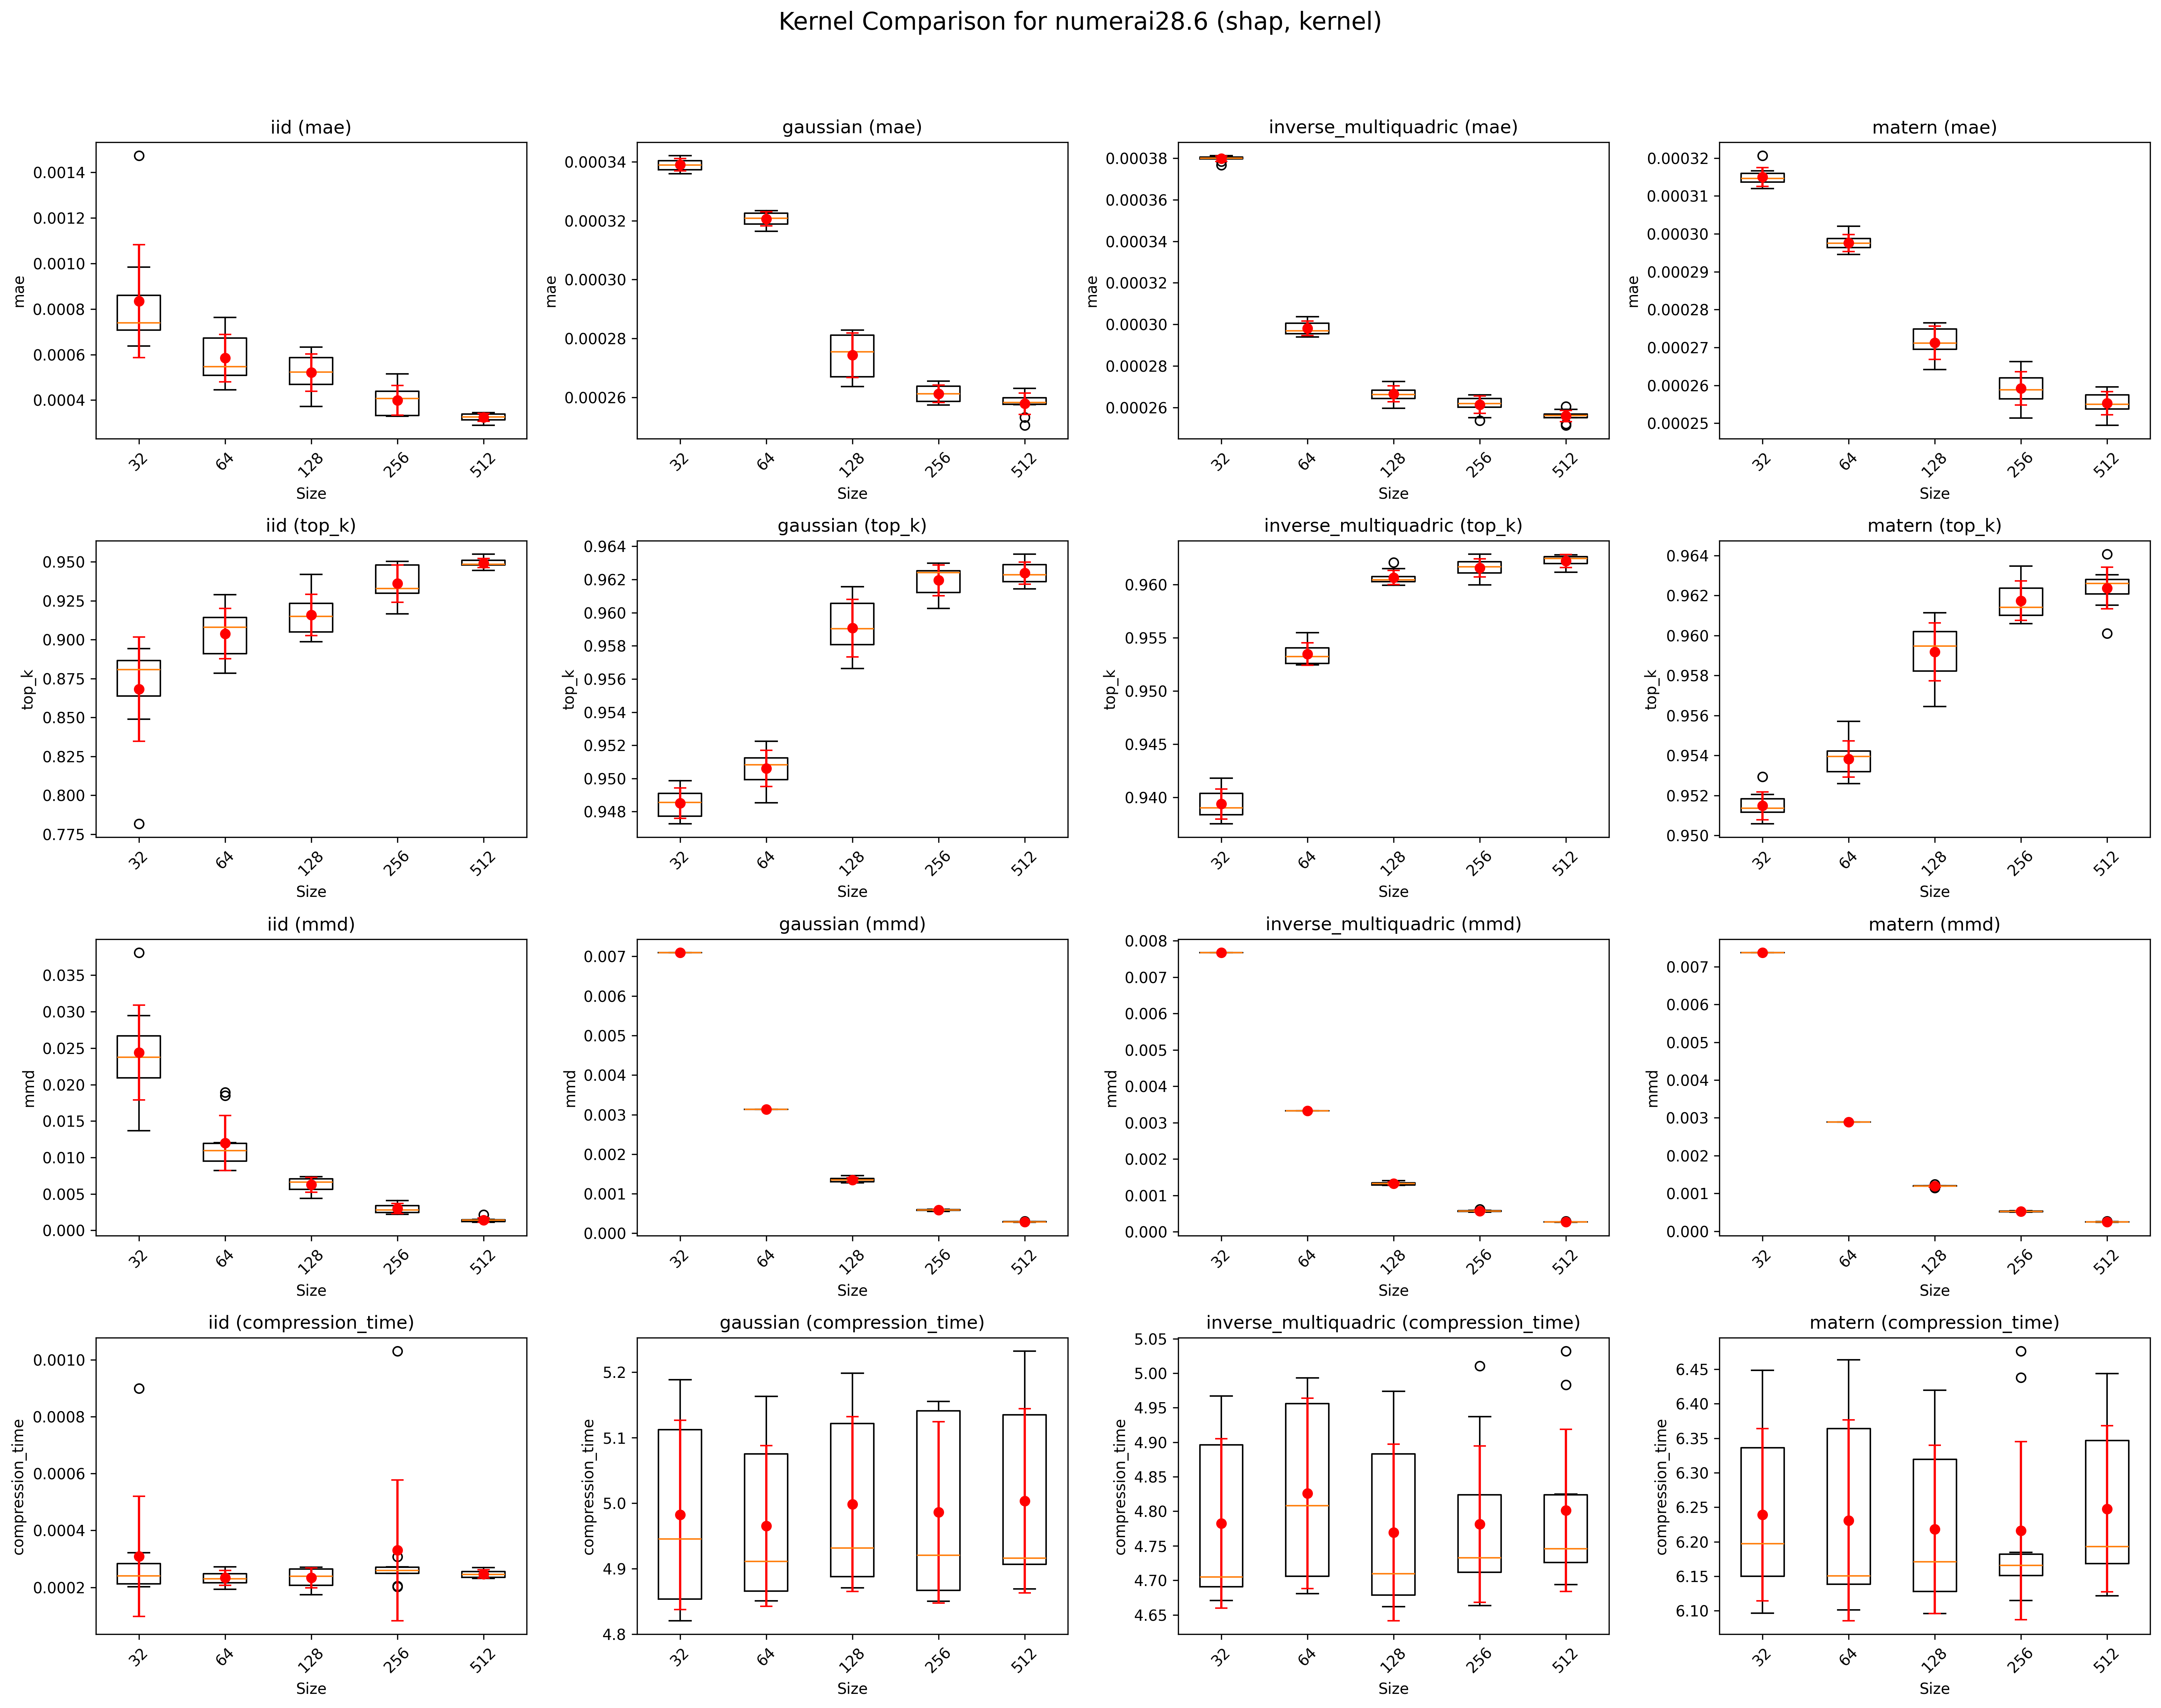

In [25]:
kernels_order = ["iid"] + [k for k in sorted(data['kernel'].unique()) if k != "iid"]

fig, axes = plt.subplots(len(metrics), len(kernels_order), figsize=(5 * len(kernels_order), 4 * len(metrics)), squeeze=False, dpi=300)
fig.suptitle(f'Kernel Comparison for {dataset_name} ({explainer_name}, {strategy})', fontsize=16)

for i, metric in enumerate(metrics):
    for j, kernel in enumerate(kernels_order):
        ax = axes[i, j]
        filtered = data[data['kernel'] == kernel]
        filtered = filtered.sort_values('size')
        ax.boxplot([filtered[filtered['size'] == s][metric] for s in sizes], labels=sizes)
        means = filtered.groupby('size')[metric].mean().reindex(sizes)
        stds = filtered.groupby('size')[metric].std().reindex(sizes)
        ax.errorbar(
            x=range(1, len(sizes) + 1),
            y=means,
            yerr=stds,
            fmt='o',
            color='red',
            capsize=4
        )
        ax.set_title(f'{kernel} ({metric})')
        ax.set_xlabel('Size')
        ax.set_ylabel(metric)
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
